In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import waveguide_solver as wgs

In [11]:
# Example of parabolic density profile
r_ch = 35e-6  # Channel radius (m)
r_cutoff = 70e-6  # Density cutoff radius (m)
shock_flat = 10e-6  # Shock transition width (m)
shock_taper = 10e-6  # Shock taper width (m)
n_e0 = 1e23   # On-axis density (m^-3)
delta_ne = 1e23  # Density difference (m^-3)
lam = 815e-9 # wavelength (m)
n_cr = wgs.critical_density(lam)  # Critical density for 800 nm light

r = np.linspace(1e-6, 1000e-6, 1000)  # Radial grid (m)
n_e = wgs.truncated_parabolic_channel(r, r_ch, r_cutoff, shock_flat, shock_taper, n_e0, delta_ne)
k0 = 2 * np.pi / lam  # Free space wavenumber (m^-1)
beta_arr = np.linspace(0.9992, 1, 1000) * k0
eta_arr = np.zeros_like(beta_arr)

for i, beta in tqdm(enumerate(beta_arr), total=len(beta_arr)):
    kappa0 = np.sqrt(k0**2 - beta**2)

    kappa2 = wgs.transverse_wavenumber(n_e, n_cr, k0, beta)

    mode_00 = wgs.solve_waveguide_fundamental_ivp(r, kappa2)
    free_space_mode_profile = wgs.free_space_mode(r, kappa0)

    r_out = wgs.calculate_rout(r, n_e)
    eta = wgs.calculate_eta(r, free_space_mode_profile, mode_00, r_out)

    eta_arr[i] = eta

100%|██████████| 1000/1000 [07:08<00:00,  2.33it/s]


Text(0, 0.5, '$\\eta$')

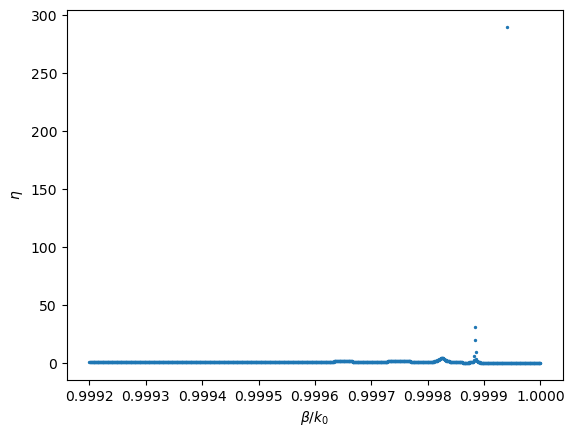

In [13]:
fig, ax = plt.subplots()
ax.scatter(beta_arr / k0, eta_arr, s=2)
ax.set_xlabel(r'$\beta / k_0$')
ax.set_ylabel(r'$\eta$')
# ax.set_xlim(0.9997, 0.9998)

Fundamental mode beta: 0.999942 m^-1


(0.0, 200.0)

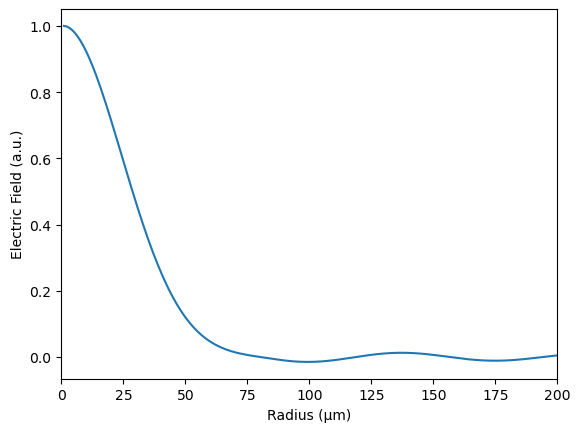

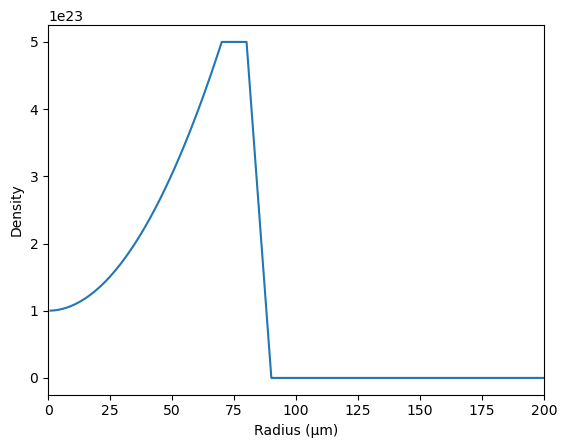

In [16]:
# Find the fundamental mode of the channel by looking for the maximum eta
max_eta_index = np.argmax(eta_arr)
beta_fundamental = beta_arr[max_eta_index]
print(f"Fundamental mode beta: {beta_fundamental/k0:.6f} m^-1")

kappa2 = wgs.transverse_wavenumber(n_e, n_cr, k0, beta_fundamental)
mode_00 = wgs.solve_waveguide_fundamental_ivp(r, kappa2)

fig, ax = plt.subplots()
ax.plot(r * 1e6, mode_00, label='Fundamental Mode')
ax.set_xlabel('Radius (µm)')
ax.set_ylabel('Electric Field (a.u.)')
ax.set_xlim(0, 200)

fig, ax = plt.subplots()
ax.plot(r * 1e6, n_e, label='Fundamental Mode')
ax.set_xlabel('Radius (µm)')
ax.set_ylabel('Density')
ax.set_xlim(0, 200)